In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


In [12]:
sla = SLA(deg=0.25).da
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()
extent_mertz =[138.5,143,-67,-65.6]


In [6]:
pressure_axis = np.arange(4,102,2)

In [13]:
meop=MEOP(extent=extent_mertz)
meop.load_profiles_for_spira(pressure_axis=pressure_axis)

100%|██████████| 81/81 [01:59<00:00,  1.47s/it]


In [14]:
elevation = GEBCO(coarsen_factor=40).ds.elevation
extent =[100,160,-69,-63]
shelf = Region('EA Shelf',extent,elevation,min_elevation=-1000)
mertz = Region('Mertz',extent_mertz)

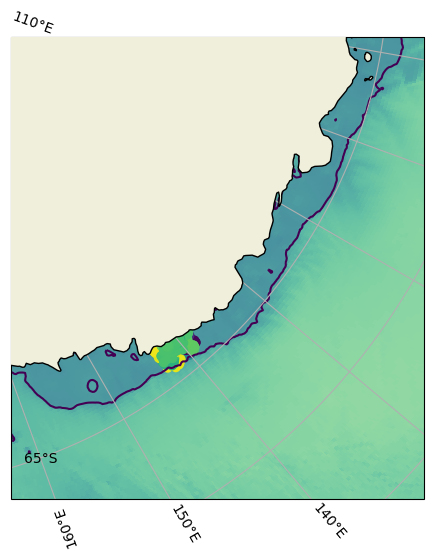

In [15]:
fig,ax=plt.subplots(figsize=(8,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
im=ax.scatter(meop.ds.lon,meop.ds.lat,c=meop.ds.time,transform=ccrs.PlateCarree())
ax.contour(elevation.longitude,elevation.latitude, elevation,levels=[-1000],transform=ccrs.PlateCarree())

In [ ]:
meop.ds['month'] = meop.ds.time.dt.month

In [17]:
def get_seasons(dspira_mertz):
    seasons={}
    seasons['autumn']=dspira_mertz.where(((dspira_mertz.month >= 4) & (dspira_mertz.month <= 6)),drop=True)
    seasons['winter']=dspira_mertz.where(((dspira_mertz.month >= 7) & (dspira_mertz.month <= 9)),drop=True)
    seasons['spring']=dspira_mertz.where(((dspira_mertz.month >= 10) & (dspira_mertz.month <= 12)),drop=True)
    seasons['summer']=dspira_mertz.where(((dspira_mertz.month >= 1) & (dspira_mertz.month <= 3)),drop=True)
    return seasons
seasons = get_seasons(meop.ds)
print(len(seasons['autumn'].time))
print(len(seasons['winter'].time))
print(len(seasons['spring'].time))
print(len(seasons['summer'].time))


3659
1151
1607
2997


In [18]:
background_data = sanom(mertz.crop_da(sla)).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

preparing data
preparing data
preparing data
preparing data
preparing data
preparing data
preparing data
preparing data


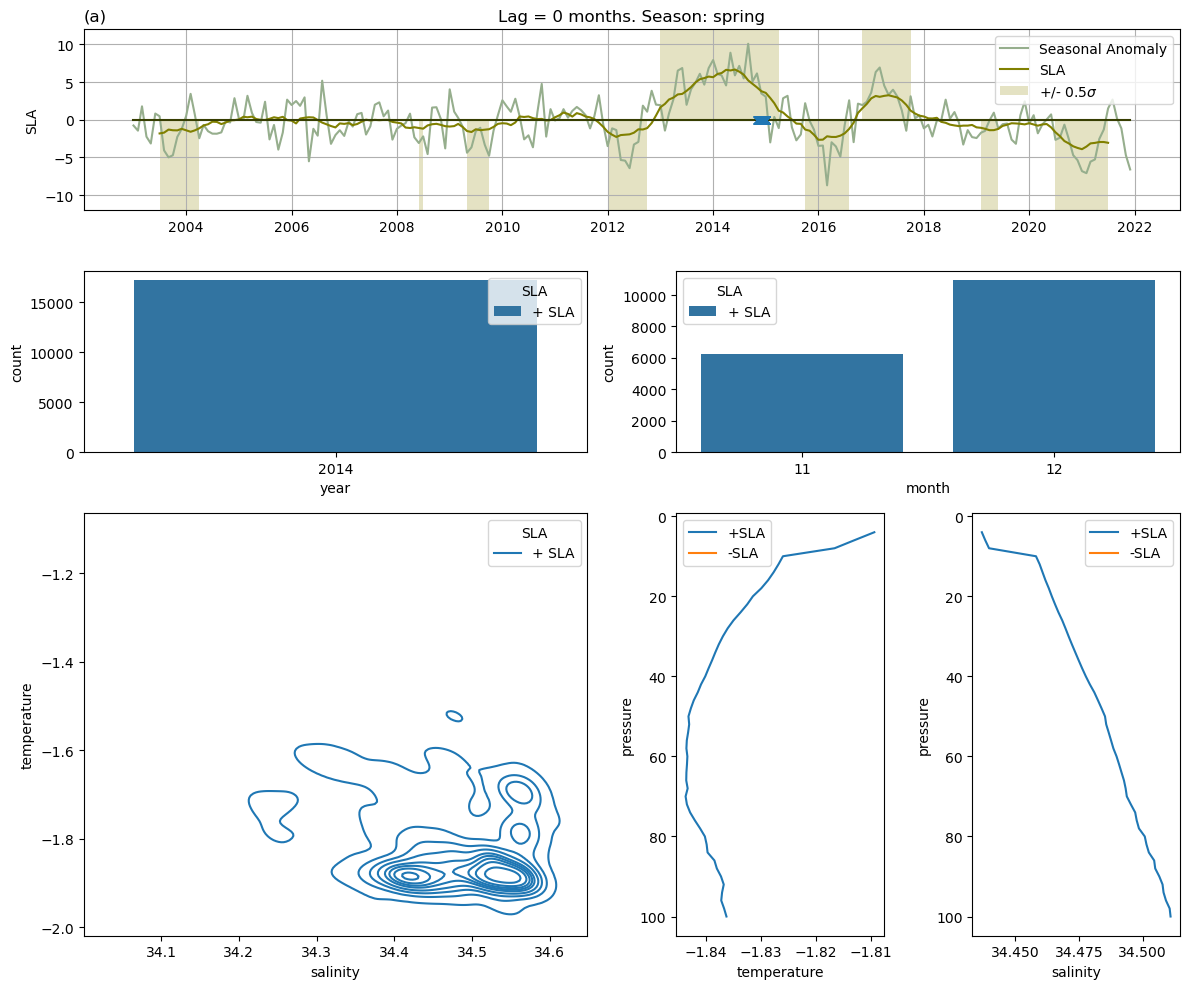

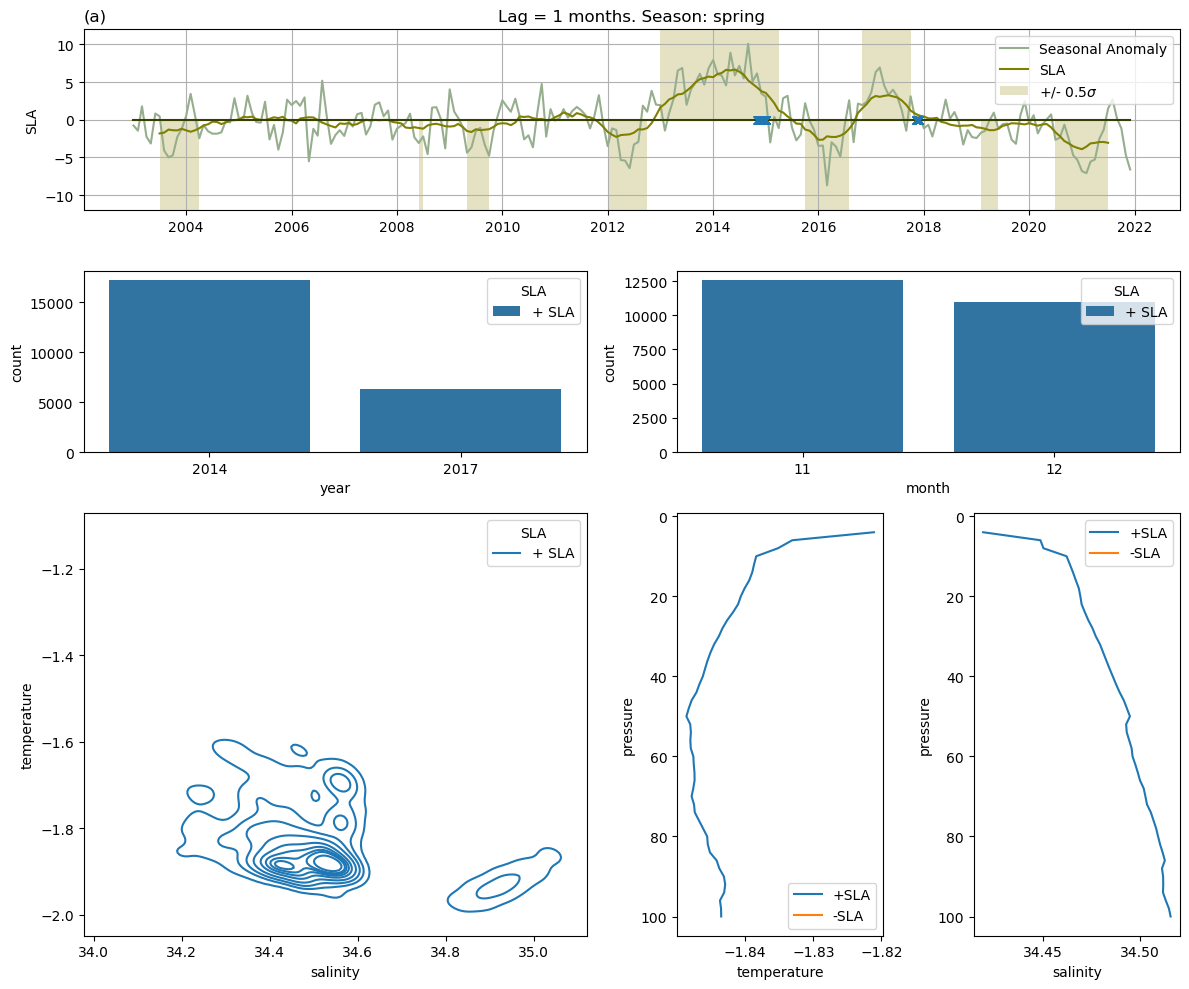

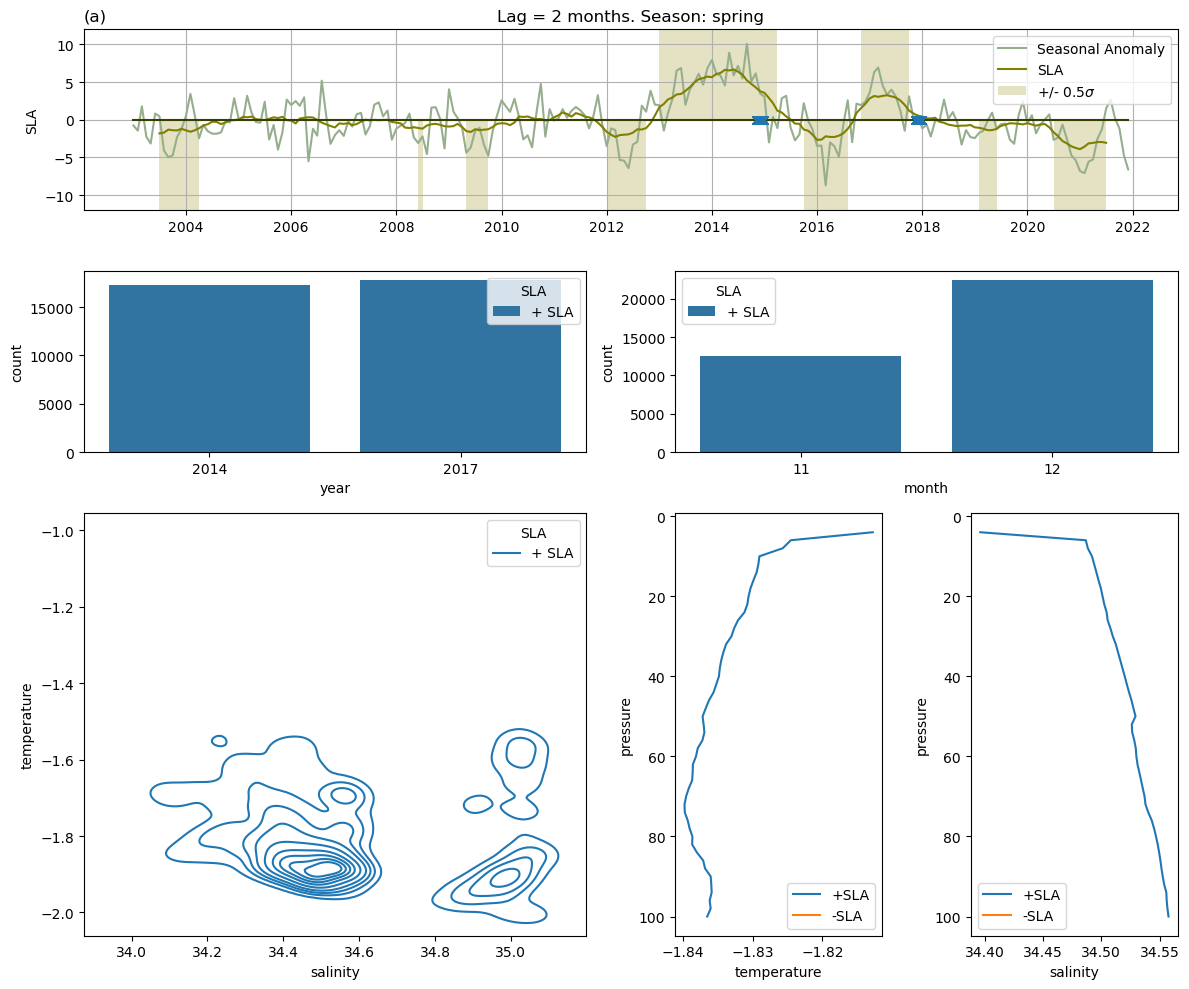

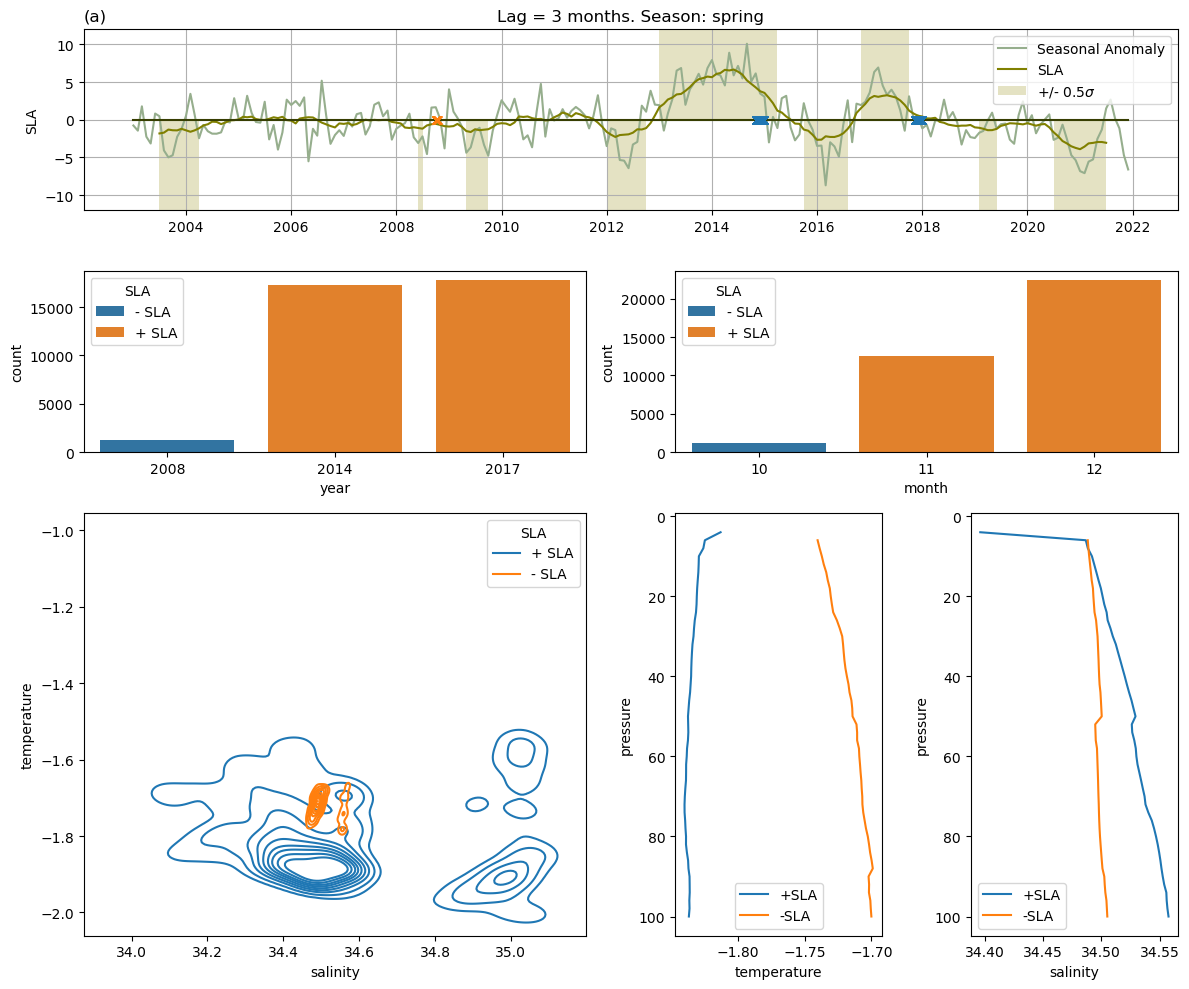

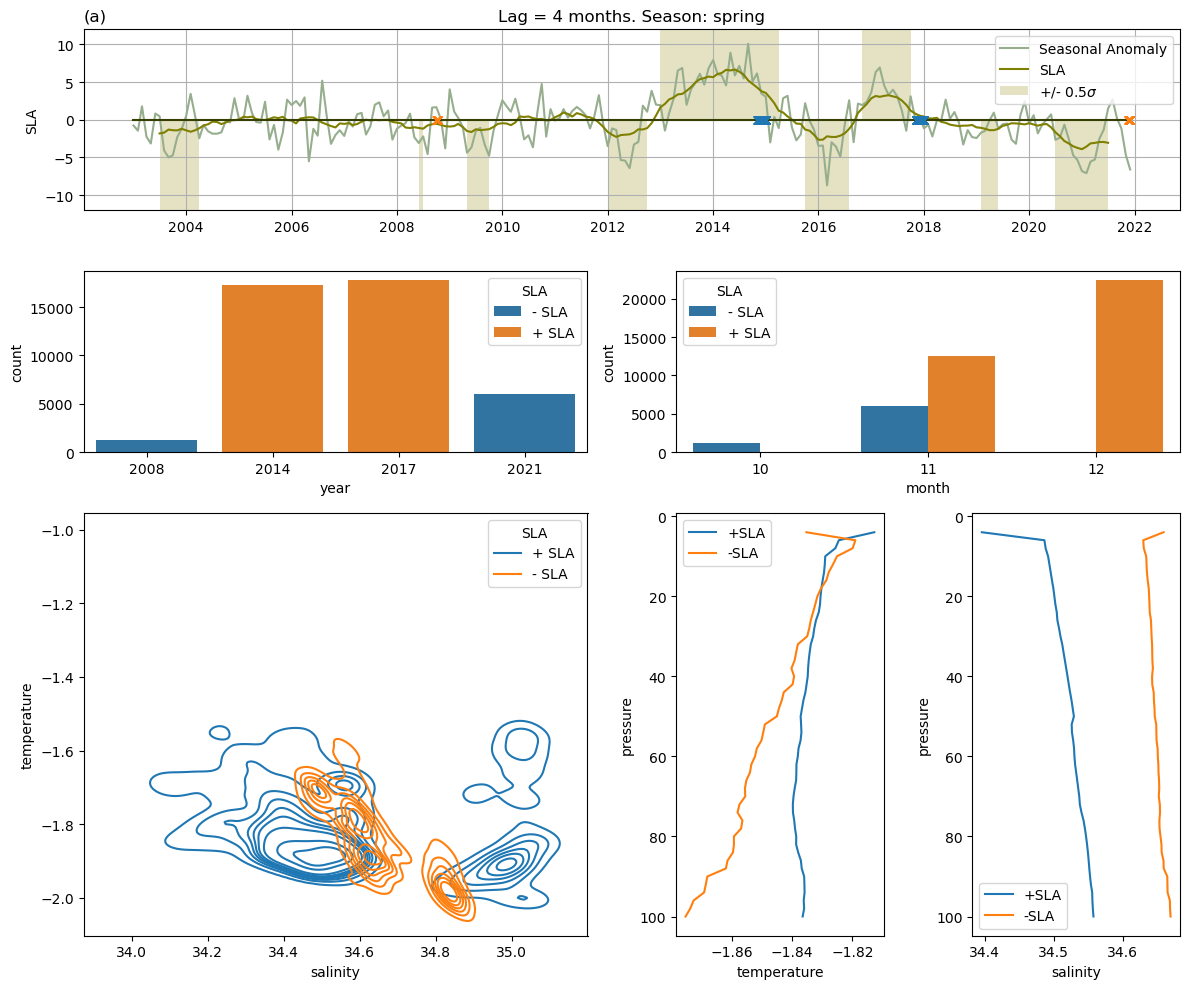

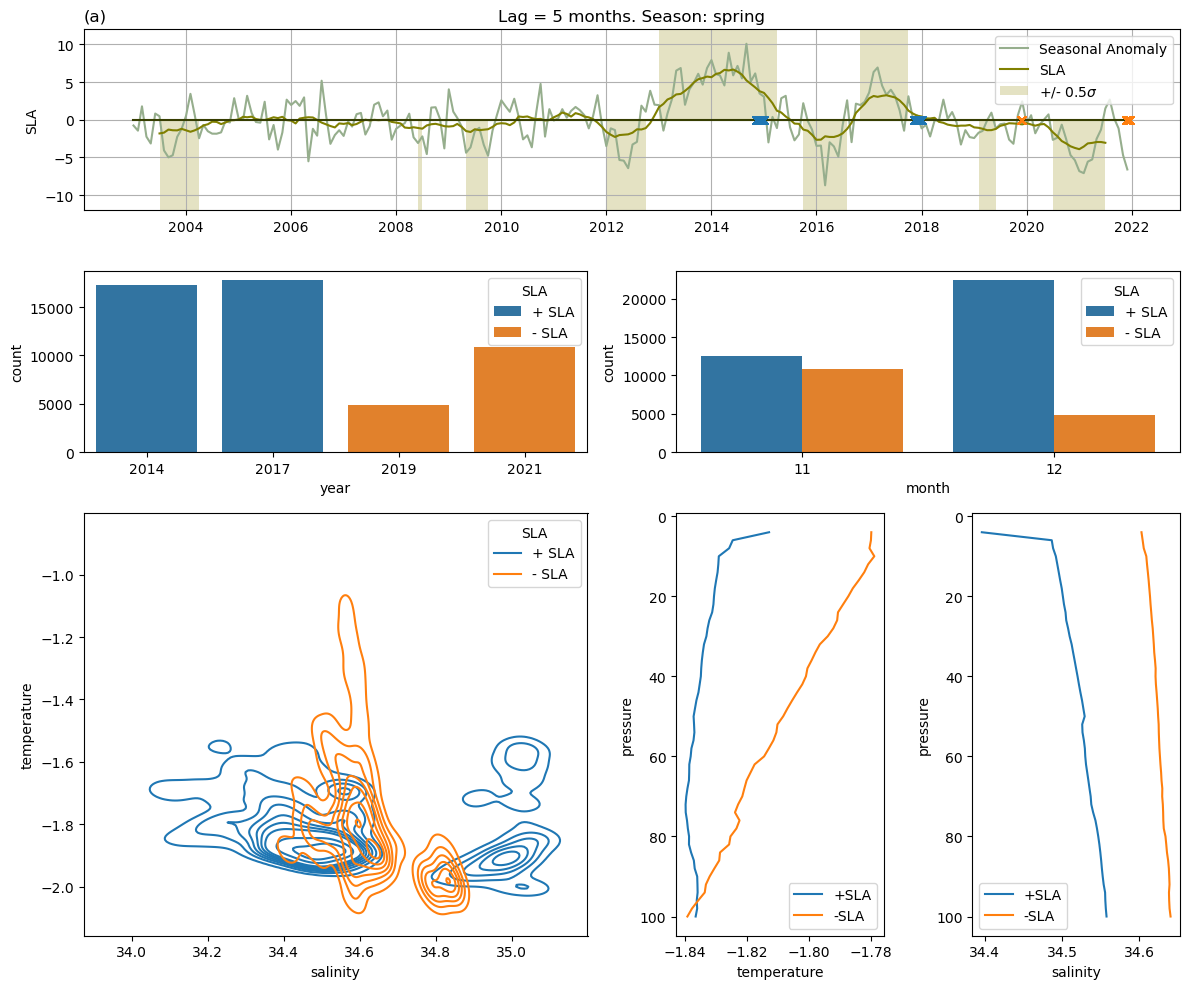

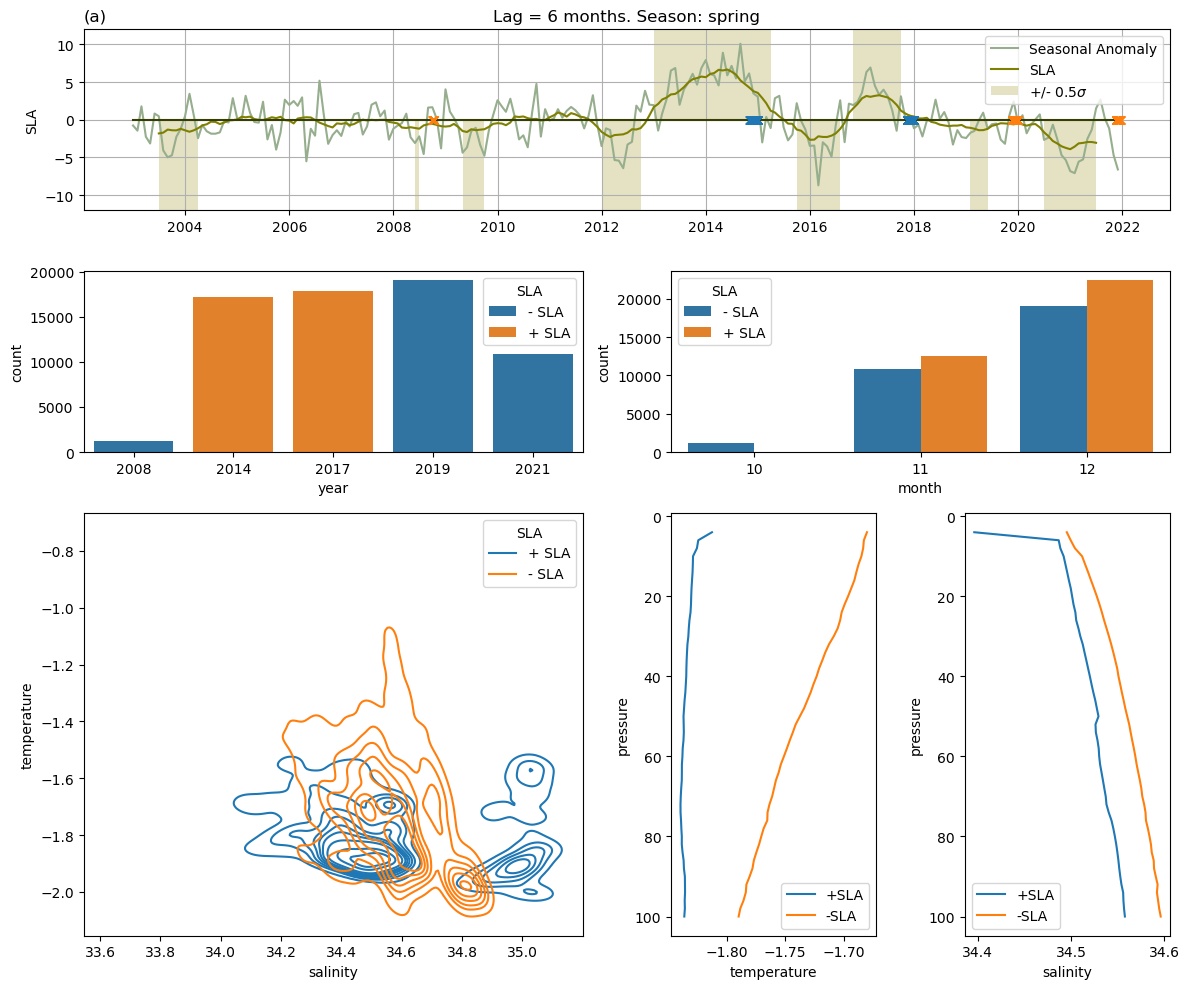

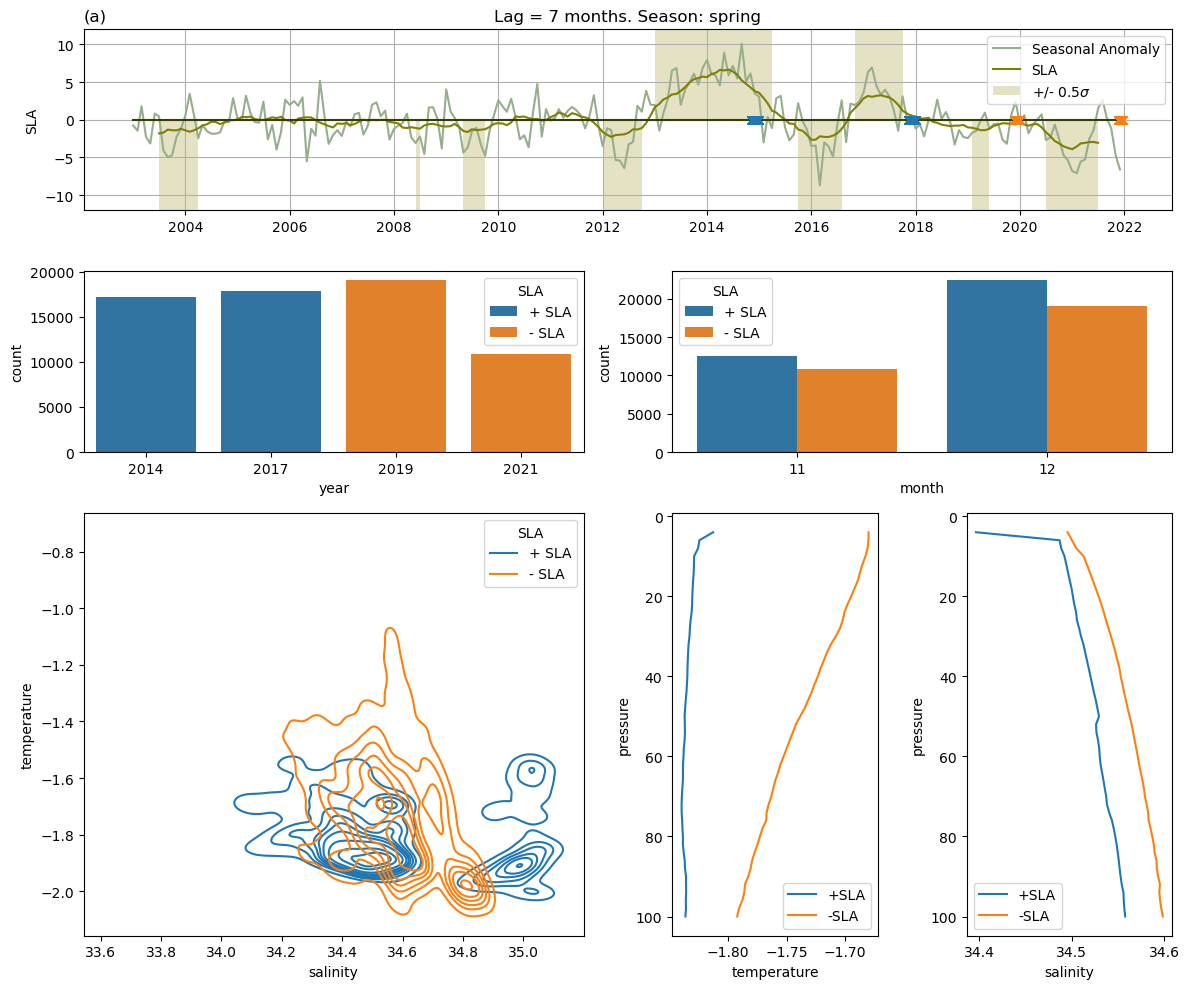

In [48]:
season='spring'
for lag in np.arange(8):
    cmp = Composite(idx_data,'SLA')
    cmp.add_spira(seasons[season],lag=lag,tlims=[-2.5,0],slims=[33.2,34.8])
    cmp.build_sns_data()

    fig = plt.figure(figsize=(12,10))
    gs = fig.add_gridspec(4,4)

    # FIG1: SLA/SAM TIMESERIES
    ax1 = fig.add_subplot(gs[0, :])
    cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
    ax1.set_title('Lag = {0} months. Season: {1}'.format(lag,season))

    # FIG2/3 month/year plots
    ax2 = fig.add_subplot(gs[1, 0:2])
    ax3 = fig.add_subplot(gs[1, 2:4])
    sns.countplot(cmp.sns_data, x='year', hue='SLA',ax=ax2)
    sns.countplot(cmp.sns_data, x='month', hue='SLA',ax=ax3)

    ax4 = fig.add_subplot(gs[2:4,0:2])
    sns.kdeplot(ax=ax4,data=cmp.sns_data,x='salinity',y='temperature',hue='SLA')

    ax5 = fig.add_subplot(gs[2:4,2])
    ax5.plot(cmp.ds_pos.temp.mean('time'),cmp.ds_pos.pressure,label='+SLA')
    ax5.plot(cmp.ds_neg.temp.mean('time'),cmp.ds_neg.pressure,label='-SLA')
    ax5.set_ylabel('pressure')
    ax5.set_xlabel('temperature')
    ax5.invert_yaxis()
    ax5.legend()

    ax6 = fig.add_subplot(gs[2:4,3])
    ax6.plot(cmp.ds_pos.psal.mean('time'),cmp.ds_pos.pressure,label='+SLA')
    ax6.plot(cmp.ds_neg.psal.mean('time'),cmp.ds_neg.pressure,label='-SLA')
    ax6.set_ylabel('pressure')
    ax6.set_xlabel('salinity')
    ax6.invert_yaxis()
    ax6.legend()

    plt.tight_layout()